In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, cross_val_score
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import GradientBoostingClassifier
from sklearn.metrics            import (roc_auc_score, classification_report,
                                        roc_curve, confusion_matrix)
from sklearn.pipeline           import Pipeline
import xgboost as xgb
from lifetimes import BetaGeoFitter
from lifetimes.utils import summary_data_from_transaction_data

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.facecolor' : '#ffffff',
    'axes.facecolor'   : '#f8f9fa',
    'axes.edgecolor'   : '#dee2e6',
    'axes.labelcolor'  : '#495057',
    'text.color'       : '#212529',
    'xtick.color'      : '#6c757d',
    'ytick.color'      : '#6c757d',
    'grid.color'       : '#e9ecef',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
events = pd.read_csv('../data/events.csv',
                     parse_dates=['event_timestamp'])
orders = pd.read_csv('../data/orders.csv',
                     parse_dates=['order_created_at'])

OBS_START  = pd.Timestamp('2023-04-01')
OBS_CUTOFF = pd.Timestamp('2023-10-01')
LABEL_END  = pd.Timestamp('2024-01-08')

# Observation window: features built from here
obs_events = events[
    (events['event_timestamp'] >= OBS_START) &
    (events['event_timestamp'] <  OBS_CUTOFF)
].copy()

# Label window: did user return after cutoff?
label_events = events[
    (events['event_timestamp'] >= OBS_CUTOFF) &
    (events['event_timestamp'] <  LABEL_END)
].copy()

obs_orders = orders[
    (orders['order_created_at'] >= OBS_START) &
    (orders['order_created_at'] <  OBS_CUTOFF)
].copy()

print(f"Observation window: {OBS_START.date()} → {OBS_CUTOFF.date()}")
print(f"Label window:       {OBS_CUTOFF.date()} → {LABEL_END.date()}")
print(f"\nObs events:  {len(obs_events):,}")
print(f"Label events:{len(label_events):,}")
print(f"Obs orders:  {len(obs_orders):,}")
print(f"\nUnique users in obs: {obs_events['user_pseudo_id'].nunique():,}")

Observation window: 2023-04-01 → 2023-10-01
Label window:       2023-10-01 → 2024-01-08

Obs events:  46,717
Label events:16,942
Obs orders:  1,007

Unique users in obs: 10,191


In [3]:
print("=" * 55)
print("CHURN LABEL CONSTRUCTION")
print("=" * 55)
print("""
Churn definition:
  Active in Apr–Oct 2023 (observation window)
  AND no activity in Oct 2023 – Jan 2024 (label window)

Non-churned: returned at least once in label window
Churned:     never returned in label window
""")

obs_users    = set(obs_events['user_pseudo_id'].unique())
active_users = set(label_events['user_pseudo_id'].unique())
churned_users = obs_users - active_users

churn_labels = pd.DataFrame({
    'user_pseudo_id': list(obs_users)
})
churn_labels['churned'] = churn_labels['user_pseudo_id'].apply(
    lambda u: 1 if u in churned_users else 0
)

overall_churn = churn_labels['churned'].mean()
print(f"Total users in observation window: {len(churn_labels):,}")
print(f"Churned users:                     {churn_labels['churned'].sum():,}")
print(f"Retained users:                    {(churn_labels['churned']==0).sum():,}")
print(f"Overall churn rate:                {overall_churn:.2%}")

CHURN LABEL CONSTRUCTION

Churn definition:
  Active in Apr–Oct 2023 (observation window)
  AND no activity in Oct 2023 – Jan 2024 (label window)

Non-churned: returned at least once in label window
Churned:     never returned in label window

Total users in observation window: 10,191
Churned users:                     8,047
Retained users:                    2,144
Overall churn rate:                78.96%


In [4]:
print("=" * 55)
print("FEATURE ENGINEERING")
print("=" * 55)
print("""
New features vs original:
  + avg_scroll_depth    (new — from enriched events)
  + intent_level_score  (new — encoded intent level)
  + dropoff_reason_mode (new — most common drop-off reason)
  + home_to_plp_rate    (new — full funnel feature)
  + plp_to_pdp_rate     (new — full funnel feature)
""")

# ── Session-level features ─────────────────────────────────────────────
session_feats = (
    obs_events.groupby('user_pseudo_id')
    .agg(
        total_sessions      = ('session_id',        'nunique'),
        total_events        = ('event_id',           'count'),
        last_visit          = ('event_timestamp',   'max'),
        first_visit         = ('event_timestamp',   'min'),
        total_pdp_views     = ('event_name',
            lambda x: (x=='view_item').sum()),
        total_plp_views     = ('event_name',
            lambda x: (x=='view_item_list').sum()),
        total_home_views    = ('event_name',
            lambda x: (x=='page_view').sum()),
        total_atc           = ('event_name',
            lambda x: (x=='add_to_cart').sum()),
        total_checkouts     = ('event_name',
            lambda x: (x=='begin_checkout').sum()),
        favorite_device     = ('device_category',
            lambda x: x.mode()[0]),
        favorite_source     = ('traffic_source',
            lambda x: x.mode()[0]),
        favorite_tier       = ('price_tier',
            lambda x: x.mode()[0]),
        favorite_category   = ('product_category',
            lambda x: x.mode()[0]),
        avg_scroll_depth    = ('scroll_depth',      'mean'),
        intent_level_mode   = ('intent_level',
            lambda x: x.mode()[0]),
        dropoff_reason_mode = ('dropoff_reason',
            lambda x: x.mode()[0]),
    )
    .reset_index()
)

# Derived session features
session_feats['days_since_last_visit'] = (
    OBS_CUTOFF - session_feats['last_visit']
).dt.days
session_feats['days_active_span'] = (
    session_feats['last_visit'] - session_feats['first_visit']
).dt.days + 1
session_feats['obs_days'] = (
    OBS_CUTOFF - pd.Timestamp('2023-04-01')
).days
session_feats['avg_sessions_per_week'] = (
    session_feats['total_sessions'] /
    (session_feats['obs_days'] / 7)
)
session_feats['pdp_per_session'] = (
    session_feats['total_pdp_views'] /
    session_feats['total_sessions'].clip(lower=1)
)
session_feats['atc_per_session'] = (
    session_feats['total_atc'] /
    session_feats['total_sessions'].clip(lower=1)
)
session_feats['home_to_plp_rate'] = (
    session_feats['total_plp_views'] /
    session_feats['total_home_views'].clip(lower=1)
).clip(upper=1.0)
session_feats['plp_to_pdp_rate'] = (
    session_feats['total_pdp_views'] /
    session_feats['total_plp_views'].clip(lower=1)
).clip(upper=1.0)

print(f"Session features built: {session_feats.shape}")
display(session_feats.head(3))

FEATURE ENGINEERING

New features vs original:
  + avg_scroll_depth    (new — from enriched events)
  + intent_level_score  (new — encoded intent level)
  + dropoff_reason_mode (new — most common drop-off reason)
  + home_to_plp_rate    (new — full funnel feature)
  + plp_to_pdp_rate     (new — full funnel feature)

Session features built: (10191, 25)


,user_pseudo_id,total_sessions,total_events,last_visit,first_visit,total_pdp_views,total_plp_views,total_home_views,total_atc,total_checkouts,favorite_device,favorite_source,favorite_tier,favorite_category,avg_scroll_depth,intent_level_mode,dropoff_reason_mode,days_since_last_visit,days_active_span,obs_days,avg_sessions_per_week,pdp_per_session,atc_per_session,home_to_plp_rate,plp_to_pdp_rate
0,uid_00020d4f,3,5,2023-08-22 12:13:12,2023-07-12 06:12:13,0,2,3,0,0,mobile,google,mid,Bundle,0.5040,high,decision_friction,39,42,183,0.1148,0.0000,0.0000,0.6667,0.0000
1,uid_000a05c9,1,3,2023-09-21 15:35:28,2023-09-21 15:34:13,1,1,1,0,0,desktop,email,mid,Bundle,0.3267,very_high,out_of_stock,9,1,183,0.0383,1.0000,0.0000,1.0000,1.0000
2,uid_000b85eb,2,3,2023-05-30 17:25:08,2023-05-22 11:24:17,0,1,2,0,0,mobile,instagram,high,Value Pack,0.5500,very_low,price_shock,123,9,183,0.0765,0.0000,0.0000,0.5000,0.0000


In [5]:
# ── Order features ─────────────────────────────────────────────────────
order_feats = (
    obs_orders.groupby('user_pseudo_id')
    .agg(
        total_orders    = ('order_id',      'nunique'),
        total_revenue   = ('order_revenue', 'sum'),
        avg_order_value = ('order_revenue', 'mean'),
        max_order_value = ('order_revenue', 'max'),
        return_count    = ('is_returned',   'sum'),
    )
    .reset_index()
)
order_feats['return_rate'] = (
    order_feats['return_count'] /
    order_feats['total_orders'].clip(lower=1)
)

# ── Merge all features ─────────────────────────────────────────────────
features = session_feats.merge(
    order_feats, on='user_pseudo_id', how='left'
)
features[['total_orders','total_revenue','avg_order_value',
          'max_order_value','return_count','return_rate']] = \
    features[['total_orders','total_revenue','avg_order_value',
              'max_order_value','return_count','return_rate']].fillna(0)

# ── Encode intent level ────────────────────────────────────────────────
intent_score_map = {
    'very_low':1, 'low':2, 'medium':3, 'high':4, 'very_high':5
}
features['intent_level_score'] = features['intent_level_mode'].map(
    intent_score_map).fillna(3)

# ── Encode drop-off reason ─────────────────────────────────────────────
reason_fixable_map = {
    'converted'         : 5,
    'decision_friction' : 4,
    'comparison_intent' : 4,
    'price_barrier'     : 3,
    'out_of_stock'      : 3,
    'distraction'       : 2,
    'price_shock'       : 2,
    'impulse_faded'     : 1,
    'ad_pdp_mismatch'   : 1,
    'wrong_audience'    : 0,
}
features['dropoff_reason_score'] = features['dropoff_reason_mode'].map(
    reason_fixable_map).fillna(2)

# ── Encode categoricals ────────────────────────────────────────────────
features = pd.get_dummies(
    features,
    columns=['favorite_device','favorite_source',
             'favorite_tier','favorite_category'],
    drop_first=False
)

print(f"Total features built: {features.shape[1]}")
print(f"\nNew features added in v2:")
for col in ['avg_scroll_depth','intent_level_score',
            'dropoff_reason_score','home_to_plp_rate',
            'plp_to_pdp_rate']:
    print(f"  {col:<30} mean={features[col].mean():.3f}")

Total features built: 46

New features added in v2:
  avg_scroll_depth               mean=0.421
  intent_level_score             mean=3.424
  dropoff_reason_score           mean=3.179
  home_to_plp_rate               mean=0.571
  plp_to_pdp_rate                mean=0.381


In [6]:
# Merge with labels
model_data = features.merge(
    churn_labels, on='user_pseudo_id', how='inner'
)

# Feature columns
drop_cols = [
    'user_pseudo_id','last_visit','first_visit',
    'churned','obs_days','intent_level_mode',
    'dropoff_reason_mode',
]
feat_cols = [c for c in model_data.columns if c not in drop_cols]

X = model_data[feat_cols].copy()
y = model_data['churned'].copy()

# Fill any remaining nulls
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Total users in model: {len(model_data):,}")
print(f"Features:             {len(feat_cols)}")
print(f"Train size:           {len(X_train):,}")
print(f"Test size:            {len(X_test):,}")
print(f"Churn rate (train):   {y_train.mean():.2%}")
print(f"Churn rate (test):    {y_test.mean():.2%}")
print(f"\nFeature list:")
for i, col in enumerate(feat_cols):
    print(f"  {i+1:>2}. {col}")

Total users in model: 10,191
Features:             40
Train size:           8,152
Test size:            2,039
Churn rate (train):   78.96%
Churn rate (test):    78.96%

Feature list:
   1. total_sessions
   2. total_events
   3. total_pdp_views
   4. total_plp_views
   5. total_home_views
   6. total_atc
   7. total_checkouts
   8. avg_scroll_depth
   9. days_since_last_visit
  10. days_active_span
  11. avg_sessions_per_week
  12. pdp_per_session
  13. atc_per_session
  14. home_to_plp_rate
  15. plp_to_pdp_rate
  16. total_orders
  17. total_revenue
  18. avg_order_value
  19. max_order_value
  20. return_count
  21. return_rate
  22. intent_level_score
  23. dropoff_reason_score
  24. favorite_device_desktop
  25. favorite_device_mobile
  26. favorite_device_tablet
  27. favorite_source_direct
  28. favorite_source_email
  29. favorite_source_google
  30. favorite_source_instagram
  31. favorite_source_referral
  32. favorite_source_tiktok
  33. favorite_tier_high
  34. favorite_tie

In [7]:
print("=" * 55)
print("MODEL 1 — LOGISTIC REGRESSION")
print("=" * 55)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced', C=1.0
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_proba  = lr_pipeline.predict_proba(X_test)[:,1]
lr_pred   = lr_pipeline.predict(X_test)
lr_auc    = roc_auc_score(y_test, lr_proba)
lr_cv_auc = cross_val_score(
    lr_pipeline, X, y, cv=5,
    scoring='roc_auc', n_jobs=-1
).mean()

print(f"Test AUC:      {lr_auc:.4f}")
print(f"CV AUC (5-fold): {lr_cv_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, lr_pred,
    target_names=['Retained','Churned']
))

# Coefficients
lr_model  = lr_pipeline.named_steps['model']
coef_df   = pd.DataFrame({
    'feature'    : feat_cols,
    'coefficient': lr_model.coef_[0],
}).sort_values('coefficient', ascending=False)

print("\nTop 10 positive coefficients (increase churn risk):")
print(coef_df.head(10)[['feature','coefficient']].to_string(index=False))
print("\nTop 10 negative coefficients (reduce churn risk):")
print(coef_df.tail(10)[['feature','coefficient']].to_string(index=False))

MODEL 1 — LOGISTIC REGRESSION
Test AUC:      0.9065
CV AUC (5-fold): 0.9131

Classification Report:
              precision    recall  f1-score   support

    Retained       0.53      0.89      0.66       429
     Churned       0.96      0.79      0.87      1610

    accuracy                           0.81      2039
   macro avg       0.75      0.84      0.77      2039
weighted avg       0.87      0.81      0.83      2039


Top 10 positive coefficients (increase churn risk):
                    feature  coefficient
      days_since_last_visit       4.0984
                return_rate       0.4994
                  total_atc       0.3236
             total_sessions       0.2374
           total_home_views       0.2374
      avg_sessions_per_week       0.2374
            pdp_per_session       0.2115
         intent_level_score       0.0751
favorite_category_Body Wash       0.0630
   favorite_category_Bundle       0.0596

Top 10 negative coefficients (reduce churn risk):
                  

In [8]:
print("=" * 55)
print("MODEL 2 — XGBOOST")
print("=" * 55)

xgb_model = xgb.XGBClassifier(
    n_estimators    = 200,
    max_depth       = 4,
    learning_rate   = 0.05,
    subsample       = 0.80,
    colsample_bytree= 0.80,
    scale_pos_weight= (y_train==0).sum()/(y_train==1).sum(),
    random_state    = 42,
    eval_metric     = 'auc',
    verbosity       = 0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_proba = xgb_model.predict_proba(X_test)[:,1]
xgb_pred  = xgb_model.predict(X_test)
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print(f"Test AUC: {xgb_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, xgb_pred,
    target_names=['Retained','Churned']
))

# Feature importance
fi_df = pd.DataFrame({
    'feature'   : feat_cols,
    'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending=False)

print(f"\nTop 15 features by importance:")
print(fi_df.head(15)[['feature','importance']].to_string(index=False))

# Check new features
print(f"\nNew feature importances:")
for feat in ['avg_scroll_depth','intent_level_score',
             'dropoff_reason_score','home_to_plp_rate',
             'plp_to_pdp_rate']:
    imp = fi_df[fi_df['feature']==feat]['importance'].values
    if len(imp):
        rank = fi_df[fi_df['feature']==feat].index[0]+1
        print(f"  {feat:<35} importance={imp[0]:.4f}  rank={rank}")

MODEL 2 — XGBOOST
Test AUC: 0.9048

Classification Report:
              precision    recall  f1-score   support

    Retained       0.51      0.95      0.66       429
     Churned       0.98      0.75      0.85      1610

    accuracy                           0.80      2039
   macro avg       0.75      0.85      0.76      2039
weighted avg       0.88      0.80      0.81      2039


Top 15 features by importance:
                      feature  importance
        avg_sessions_per_week      0.3221
        days_since_last_visit      0.2757
             total_home_views      0.0648
               total_sessions      0.0479
             days_active_span      0.0182
            favorite_tier_low      0.0132
              total_plp_views      0.0125
     favorite_category_Bundle      0.0120
favorite_category_Conditioner      0.0098
              total_checkouts      0.0095
       favorite_source_google      0.0094
 favorite_category_Value Pack      0.0094
                 total_events      0

In [9]:
print("=" * 55)
print("MODEL 3 — BG/NBD (PROBABILISTIC)")
print("=" * 55)
print("""
BG/NBD does not require a churn label.
It estimates P(alive) directly from purchase behavior:
  - frequency: number of repeat purchases
  - recency:   time between first and last purchase
  - T:         total observation time

P(alive) < 0.5 → user is likely churned
P(alive) > 0.5 → user is likely still active
""")

bgf_data = summary_data_from_transaction_data(
    obs_orders,
    customer_id_col        = 'user_pseudo_id',
    datetime_col           = 'order_created_at',
    observation_period_end = OBS_CUTOFF,
    freq                   = 'D',
)

print(f"Users for BG/NBD: {len(bgf_data):,}")
print(f"Repeat purchasers (freq>0): {(bgf_data['frequency']>0).sum():,}")

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    bgf_data['frequency'],
    bgf_data['recency'],
    bgf_data['T'],
)

print(f"\nBG/NBD model fitted ✓")
print(bgf.summary.round(4).to_string())

bgf_data['p_alive'] = bgf.conditional_probability_alive(
    bgf_data['frequency'],
    bgf_data['recency'],
    bgf_data['T'],
)
bgf_data['predicted_purchases_90d'] = \
    bgf.conditional_expected_number_of_purchases_up_to_time(
        90,
        bgf_data['frequency'],
        bgf_data['recency'],
        bgf_data['T'],
    )

bgf_data['bgnbd_churned'] = (bgf_data['p_alive'] < 0.50).astype(int)

print(f"\nP(alive) summary:")
print(bgf_data['p_alive'].describe().round(3).to_string())
print(f"\nBG/NBD churn rate: {bgf_data['bgnbd_churned'].mean():.2%}")

MODEL 3 — BG/NBD (PROBABILISTIC)

BG/NBD does not require a churn label.
It estimates P(alive) directly from purchase behavior:
  - frequency: number of repeat purchases
  - recency:   time between first and last purchase
  - T:         total observation time

P(alive) < 0.5 → user is likely churned
P(alive) > 0.5 → user is likely still active

Users for BG/NBD: 915
Repeat purchasers (freq>0): 84

BG/NBD model fitted ✓
         coef  se(coef)  lower 95% bound  upper 95% bound
r      0.1240    0.0290           0.0672           0.1807
alpha 60.4082   19.0522          23.0658          97.7506
a      0.1625    0.1840          -0.1982           0.5232
b      0.0409    0.0487          -0.0546           0.1364

P(alive) summary:
count   915.0000
mean      0.9250
std       0.2430
min       0.0660
25%       1.0000
50%       1.0000
75%       1.0000
max       1.0000

BG/NBD churn rate: 8.42%


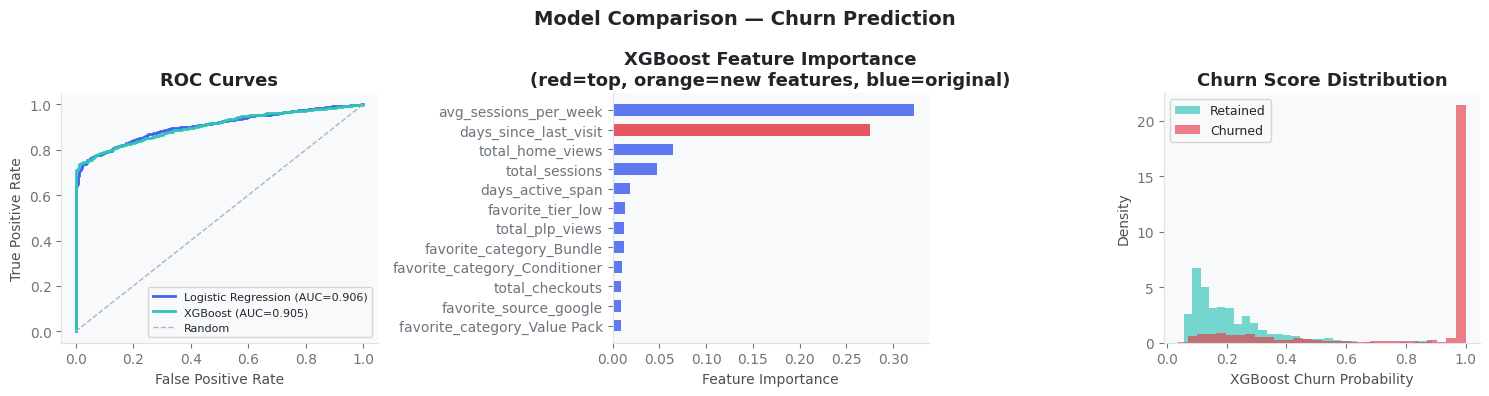


Model comparison:
  Logistic Regression AUC: 0.9065
  XGBoost AUC:             0.9048
  Difference:              0.0017
  → Near-identical AUC: churn signal is largely linear
    Confidence is in features, not model complexity


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model Comparison — Churn Prediction',
             fontsize=14, fontweight='bold')

# ROC curves
ax = axes[0]
for proba, label, color in [
    (lr_proba,  f'Logistic Regression (AUC={lr_auc:.3f})', '#4361ee'),
    (xgb_proba, f'XGBoost (AUC={xgb_auc:.3f})',            '#2ec4b6'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=label)

ax.plot([0,1],[0,1], color='#adb5bd', linestyle='--',
        linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(fontsize=8)

# Feature importance (XGBoost top 12)
ax2 = axes[1]
fi_top = fi_df.head(12).sort_values('importance', ascending=True)
new_feats = ['avg_scroll_depth','intent_level_score',
             'dropoff_reason_score','home_to_plp_rate',
             'plp_to_pdp_rate']
bar_colors = [
    '#e63946' if f=='days_since_last_visit' else
    '#f9a825' if f in new_feats else
    '#4361ee'
    for f in fi_top['feature']
]
ax2.barh(fi_top['feature'], fi_top['importance'],
         color=bar_colors, height=0.6, alpha=0.85)
ax2.set_xlabel('Feature Importance')
ax2.set_title('XGBoost Feature Importance\n'
              '(red=top, orange=new features, blue=original)')

# Churn probability distribution
ax3 = axes[2]
ax3.hist(xgb_proba[y_test==0], bins=30, alpha=0.65,
         color='#2ec4b6', label='Retained', density=True)
ax3.hist(xgb_proba[y_test==1], bins=30, alpha=0.65,
         color='#e63946', label='Churned', density=True)
ax3.set_xlabel('XGBoost Churn Probability')
ax3.set_ylabel('Density')
ax3.set_title('Churn Score Distribution')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/churn_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nModel comparison:")
print(f"  Logistic Regression AUC: {lr_auc:.4f}")
print(f"  XGBoost AUC:             {xgb_auc:.4f}")
print(f"  Difference:              {abs(xgb_auc-lr_auc):.4f}")
if abs(xgb_auc-lr_auc) < 0.01:
    print(f"  → Near-identical AUC: churn signal is largely linear")
    print(f"    Confidence is in features, not model complexity")

In [11]:
print("=" * 55)
print("SCORING ALL USERS")
print("=" * 55)

# Score full dataset
X_all     = model_data[feat_cols].fillna(0)
xgb_all   = xgb_model.predict_proba(X_all)[:,1]
lr_all    = lr_pipeline.predict_proba(X_all)[:,1]

churn_scores = model_data[['user_pseudo_id','churned']].copy()
churn_scores['xgb_churn_prob'] = xgb_all
churn_scores['lr_churn_prob']  = lr_all

# Add key features for dashboard
for col in ['days_since_last_visit','total_sessions',
            'total_orders','total_revenue','avg_order_value',
            'avg_scroll_depth','intent_level_score',
            'dropoff_reason_score']:
    if col in model_data.columns:
        churn_scores[col] = model_data[col].values

# Add categorical features
for col in ['favorite_device','favorite_source']:
    if col in session_feats.columns:
        churn_scores = churn_scores.merge(
            session_feats[['user_pseudo_id',col]],
            on='user_pseudo_id', how='left'
        )

# Risk tiers
churn_scores['churn_risk_tier'] = pd.cut(
    churn_scores['xgb_churn_prob'],
    bins   = [0, 0.40, 0.70, 1.0],
    labels = ['Low Risk','Medium Risk','High Risk']
)

print(f"Users scored: {len(churn_scores):,}")
print(f"\nRisk tier distribution:")
print(churn_scores['churn_risk_tier'].value_counts().to_string())
print(f"\nChurn prob summary:")
print(churn_scores['xgb_churn_prob'].describe().round(3).to_string())

SCORING ALL USERS
Users scored: 10,191

Risk tier distribution:
churn_risk_tier
High Risk      6029
Low Risk       3553
Medium Risk     609

Churn prob summary:
count   10191.0000
mean        0.6830
std         0.3820
min         0.0360
25%         0.2420
50%         0.9990
75%         0.9990
max         1.0000


In [12]:
print("=" * 55)
print("NEW FEATURE VALIDATION")
print("=" * 55)
print("""
Do the new features (scroll depth, intent level,
drop-off reason) add signal beyond the original features?
We check this by comparing AUC with and without new features.
""")

# Original features only
original_feats = [c for c in feat_cols if c not in [
    'avg_scroll_depth','intent_level_score',
    'dropoff_reason_score','home_to_plp_rate',
    'plp_to_pdp_rate'
]]
new_only_feats = [
    'avg_scroll_depth','intent_level_score',
    'dropoff_reason_score','home_to_plp_rate',
    'plp_to_pdp_rate'
]

# Original features model
xgb_orig = xgb.XGBClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, random_state=42,
    verbosity=0
)
xgb_orig.fit(X_train[original_feats], y_train)
auc_orig = roc_auc_score(
    y_test, xgb_orig.predict_proba(
        X_test[original_feats])[:,1])

# Full model
auc_full = xgb_auc

print(f"AUC — Original features only:   {auc_orig:.4f}")
print(f"AUC — All features (incl. new): {auc_full:.4f}")
print(f"AUC improvement from new feats: {auc_full-auc_orig:+.4f}")

# Correlation of new features with churn
print(f"\nCorrelation of new features with churn label:")
for feat in new_only_feats:
    if feat in model_data.columns:
        corr = model_data[feat].corr(model_data['churned'])
        print(f"  {feat:<35} r={corr:+.3f}")

# Days since last visit distribution by new feature segments
print(f"\nAvg days_since_last_visit by intent level:")
intent_churn = (
    model_data.groupby('intent_level_mode')
    .agg(
        avg_days    = ('days_since_last_visit','mean'),
        churn_rate  = ('churned','mean'),
        users       = ('churned','count'),
    )
    .reset_index()
    .sort_values('churn_rate', ascending=False)
)
print(intent_churn.round(3).to_string(index=False))

NEW FEATURE VALIDATION

Do the new features (scroll depth, intent level,
drop-off reason) add signal beyond the original features?
We check this by comparing AUC with and without new features.

AUC — Original features only:   0.9054
AUC — All features (incl. new): 0.9048
AUC improvement from new feats: -0.0006

Correlation of new features with churn label:
  avg_scroll_depth                    r=+0.009
  intent_level_score                  r=+0.028
  dropoff_reason_score                r=+0.032
  home_to_plp_rate                    r=+0.007
  plp_to_pdp_rate                     r=+0.038

Avg days_since_last_visit by intent level:
intent_level_mode  avg_days  churn_rate  users
        very_high   62.9490      0.8000   2881
             high   62.4310      0.7950   2948
           medium   66.8690      0.7930    397
              low   63.9080      0.7830   3536
         very_low   65.7370      0.7320    429


In [13]:
churn_scores.to_csv('../data/churn_scores.csv', index=False)

print(f"Saved churn_scores.csv")
print(f"  Rows:    {len(churn_scores):,}")
print(f"  Columns: {churn_scores.columns.tolist()}")

Saved churn_scores.csv
  Rows:    10,191
  Columns: ['user_pseudo_id', 'churned', 'xgb_churn_prob', 'lr_churn_prob', 'days_since_last_visit', 'total_sessions', 'total_orders', 'total_revenue', 'avg_order_value', 'avg_scroll_depth', 'intent_level_score', 'dropoff_reason_score', 'favorite_device', 'favorite_source', 'churn_risk_tier']


In [14]:
print("=" * 65)
print("CHURN MODEL SUMMARY")
print("=" * 65)

high_risk   = (churn_scores['churn_risk_tier']=='High Risk').sum()
medium_risk = (churn_scores['churn_risk_tier']=='Medium Risk').sum()
low_risk    = (churn_scores['churn_risk_tier']=='Low Risk').sum()
total_users = len(churn_scores)

top_feature = fi_df.iloc[0]['feature']
top_imp     = fi_df.iloc[0]['importance']

new_feat_rank = {}
for feat in ['avg_scroll_depth','intent_level_score','dropoff_reason_score']:
    rows = fi_df[fi_df['feature']==feat]
    if len(rows):
        new_feat_rank[feat] = (
            fi_df.index.get_loc(rows.index[0]) + 1,
            rows['importance'].values[0]
        )

print(f"""
CHURN DEFINITION
  Active:  Apr–Oct 2023
  Churned: No return in Oct 2023–Jan 2024
  Rate:    {overall_churn:.2%}

MODEL PERFORMANCE
  Logistic Regression AUC: {lr_auc:.4f}
  XGBoost AUC:             {xgb_auc:.4f}
  CV AUC (5-fold, LR):     {lr_cv_auc:.4f}
  Near-identical → signal is largely linear

TOP FEATURES (XGBoost)
  #1: {fi_df.iloc[0]['feature']:<35} {fi_df.iloc[0]['importance']:.4f}
  #2: {fi_df.iloc[1]['feature']:<35} {fi_df.iloc[1]['importance']:.4f}
  #3: {fi_df.iloc[2]['feature']:<35} {fi_df.iloc[2]['importance']:.4f}

NEW FEATURES (v2 additions)""")

for feat, (rank, imp) in new_feat_rank.items():
    print(f"  {feat:<35} rank={rank}  importance={imp:.4f}")

print(f"""
NEW FEATURE AUC IMPROVEMENT
  Without new features: {auc_orig:.4f}
  With new features:    {auc_full:.4f}
  Improvement:          {auc_full-auc_orig:+.4f}

RISK TIER DISTRIBUTION
  High Risk:   {high_risk:,} ({high_risk/total_users:.1%})
  Medium Risk: {medium_risk:,} ({medium_risk/total_users:.1%})
  Low Risk:    {low_risk:,} ({low_risk/total_users:.1%})

BG/NBD MODEL
  Purchasers modeled: {len(bgf_data):,}
  Avg P(alive):       {bgf_data['p_alive'].mean():.2f}
  Likely churned (P<0.5): {bgf_data['bgnbd_churned'].sum():,}

OUTPUT
  churn_scores.csv — {len(churn_scores):,} users scored
""")
print("=" * 65)
print("→ Next: 08_retention_model.ipynb")

CHURN MODEL SUMMARY

CHURN DEFINITION
  Active:  Apr–Oct 2023
  Churned: No return in Oct 2023–Jan 2024
  Rate:    78.96%

MODEL PERFORMANCE
  Logistic Regression AUC: 0.9065
  XGBoost AUC:             0.9048
  CV AUC (5-fold, LR):     0.9131
  Near-identical → signal is largely linear

TOP FEATURES (XGBoost)
  #1: avg_sessions_per_week               0.3221
  #2: days_since_last_visit               0.2757
  #3: total_home_views                    0.0648

NEW FEATURES (v2 additions)
  avg_scroll_depth                    rank=21  importance=0.0078
  intent_level_score                  rank=22  importance=0.0076
  dropoff_reason_score                rank=35  importance=0.0066

NEW FEATURE AUC IMPROVEMENT
  Without new features: 0.9054
  With new features:    0.9048
  Improvement:          -0.0006

RISK TIER DISTRIBUTION
  High Risk:   6,029 (59.2%)
  Medium Risk: 609 (6.0%)
  Low Risk:    3,553 (34.9%)

BG/NBD MODEL
  Purchasers modeled: 915
  Avg P(alive):       0.93
  Likely churned (P<